In [2]:
import numpy as np
def analyze(filepath, cut = 10000):
    try:
        with open(filepath, 'r', errors="ignore") as f:
            content = f.read()
    except:
        print('error of file:', filepath)
        raise Exception("HAHA")

    search_depth = []
    steps = []
    prediction_correctness = []
    visited_positions = []
    visited_criricals = []
    game_info = []

    for s in content.split('@'):
        # print(s)
        # print('------------------')
        # s = s.split('\n')
        if len(s) == 0:
            continue
        step = s.split('\n')[0].split('step')[1]
        try:
            step = int(step)
        except:
            print(s.split('\n')[0])
            print(s)
            print(filepath)
            raise Exception('invalid step')
        if step >= cut:
            break
        move = None
        rate = None
        depth = None
        vis = None
        vis_critical = None
        for line in s.split('\n'):
            if "optimal move:" in line:
                move = line.split("optimal move:")[-1]
                continue
            if "success rate" in line:
                if 'nan' in line:
                    continue;
                rate = eval(line.split('success rate: ')[-1])
                continue
            if 'depth' in line:
                depth = eval(line.split('depth:')[-1])
            if 'visited positions:' in line:
                vis = eval(line.split('visited positions:')[-1])
            if 'visited criticals:' in line:
                vis_critical = eval(line.split('visited criticals:')[-1])
        if move is None:
            continue

        # print('move:', move)
        # print('rate:', rate)
        # print('depth:', depth)

        round_info = {
            'depth' : depth,
            'prediction rate': rate,
            'move': move,
            'visited': vis,
            'criticals': vis_critical
        }
        if vis is None:
            # print(round_info)
            # print(s)
            break

        steps.append(step)
        search_depth.append(depth)
        prediction_correctness.append(rate)
        game_info.append(round_info)
        visited_positions.append(vis - vis_critical)
        visited_criricals.append(vis_critical)

    search_depth = np.array(search_depth)
    prediction_correctness = np.array(prediction_correctness)
    visited_positions = np.array(visited_positions)
    visited_criricals = np.array(visited_criricals)

    return steps, {
        'depth': search_depth.copy(),
        'prediction' : prediction_correctness.copy(),
        'visited_normal': visited_positions.copy(),
        'criticals': visited_criricals.copy()
    }

In [3]:
import os
import matplotlib.pyplot as plt
def analyze_avg(record_path, max_step = 60):
    # record_path = '/mnt/20F408ADF408876E/TCG/TCG_final/submission/record_depth_0'
    plt.figure(figsize=(12, 8))

    depth = np.zeros(max_step)
    N = np.zeros(max_step)
    prediction = np.zeros(max_step)
    visited = np.zeros(max_step)
    criticals = np.zeros(max_step)

    # N = 0

    for f in os.listdir(record_path):
        filepath = os.path.join(record_path, f)
        if not '.txt' in filepath:
            continue
        info = analyze(filepath, max_step)

        steps = info[0]
        info = info[1]
        visited_positions = info['visited_normal']
        visited_criricals = info['criticals']
        prediction_correctness = info['prediction']
        search_depth = info['depth']

        depth[steps] += search_depth
        prediction[steps] += prediction_correctness
        visited[steps] += visited_positions
        criticals[steps] += visited_criricals
        N[steps] += 1

    steps = range(max_step)

    visited /= N
    criticals /= N
    prediction /= N
    depth /= N

    return steps, (visited, criticals, visited + criticals), prediction, depth
    # plt.subplot(2,2,1)
    # plt.plot(steps, visited, label = 'visitd')
    # plt.plot(steps, criticals, label = 'critical')
    # plt.plot(steps, visited+criticals+100000 , label = 'total')
    # plt.legend()
    # plt.title('visited normal/critical nodes')

    # plt.subplot(2,2,2)
    # plt.plot(steps, prediction)
    # plt.title('move-ordering corectness')
    # plt.legend()

    # plt.subplot(2,2,3)
    # plt.plot(steps, depth)
    # plt.ylim(0, 10)
    # plt.title('search depth')

    # plt.show()

    # print('number of data:', len(os.listdir(record_path)))

In [4]:
#steps, (visited, criticals, visited + criticals), prediction, depth

In [ ]:
normal_path = '/mnt/20F408ADF408876E/TCG/TCG_final/submission/record_depth6'
no_q_path = '/mnt/20F408ADF408876E/TCG/TCG_final/submission/record'

max_steps = 60

steps, (_, _ , visited_6), _, depth_6 = analyze_avg(normal_path, max_steps)
steps, (_, _ , visited_0), _, depth_0 = analyze_avg(no_q_path, max_steps)

# plt.subplot(2,2,1)
# plt.plot(steps, visited, label = 'visitd')
# plt.plot(steps, criticals, label = 'critical')
# plt.plot(steps, visited+criticals+100000 , label = 'total')
# plt.legend()
# plt.title('visited normal/critical nodes')

# plt.subplot(2,2,2)
# plt.plot(steps, prediction)
# plt.title('move-ordering corectness')
# plt.legend()

# plt.subplot(2,2,3)
# plt.plot(steps, depth)
plt.figure(figsize = (8,12))

plt.subplot(2,1,1)
plt.plot(steps, depth_6, label = 'quiescence search')
plt.plot(steps, depth_0, label = 'no-quiescence')
plt.ylim(0, 10)
plt.xlabel('steps')
plt.ylabel('depth')
plt.title('search depth')
plt.legend()

plt.subplot(2,1,2)

plt.plot(steps, visited_6, label = 'quiescence search')
plt.plot(steps, visited_0, label = 'no-quiescence')
plt.xlabel('steps')
plt.ylabel('depth')
plt.title('number of Negamax calls')
plt.legend()

plt.show()

print('number of data:', len(os.listdir(normal_path)))

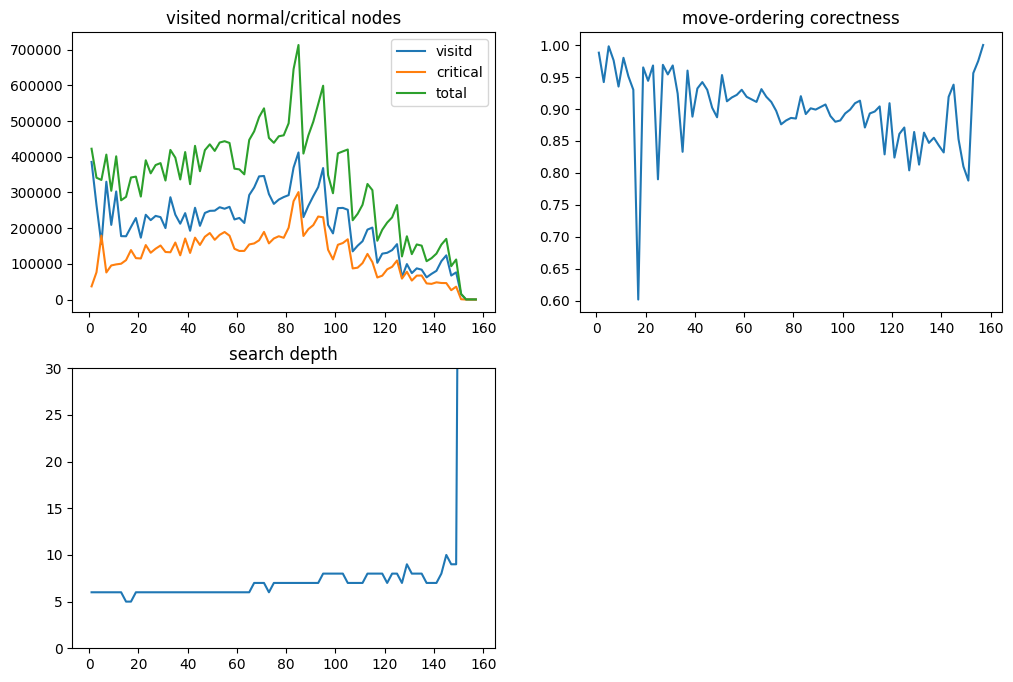

In [ ]:
import matplotlib.pyplot as plt
file_path = input()
steps, analyzation = analyze(file_path)

visited_positions = analyzation['visited_normal']
visited_criricals = analyzation['criticals']

prediction_correctness = analyzation['prediction']
search_depth = analyzation['depth']

plt.figure(figsize=(12, 8))
plt.subplot(2,2,1)

plt.plot(steps, visited_positions, label = 'visitd')
plt.plot(steps, visited_criricals, label = 'critical')
plt.plot(steps, [x+y for(x,y) in zip(visited_positions, visited_criricals)], label = 'total')
plt.legend()
plt.title('visited normal/critical nodes')

plt.subplot(2,2,2)
plt.plot(steps, prediction_correctness)
plt.title('move-ordering correctness')
# plt.legend()

plt.subplot(2,2,3)
plt.plot(steps, search_depth)
plt.ylim(0, 30)
plt.title('search depth')

plt.show()

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

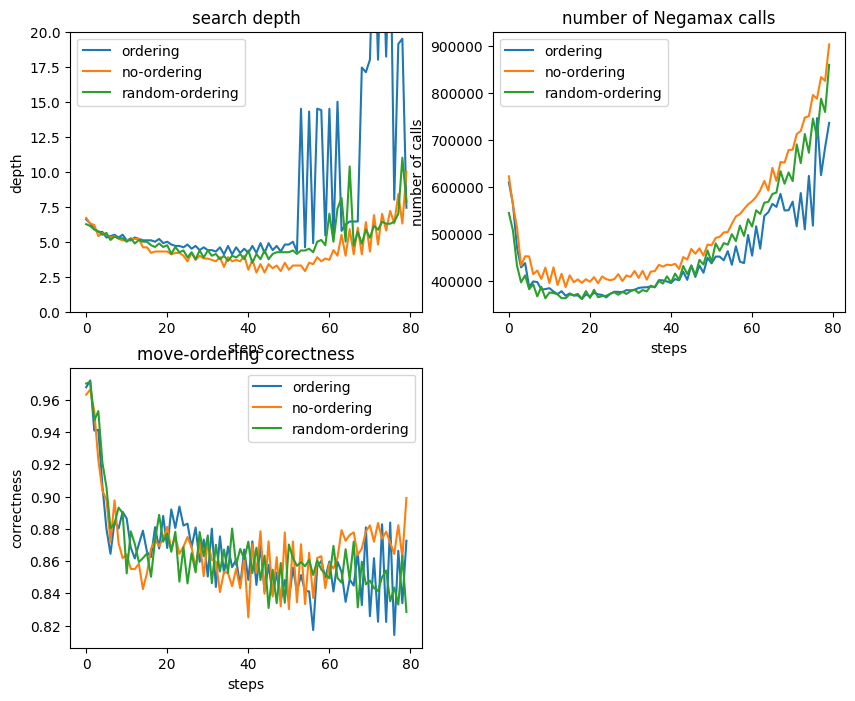

number of data: 20


In [24]:
normal_path = '/mnt/20F408ADF408876E/TCG/TCG_final/submission/record'
no_ordering_path = '/mnt/20F408ADF408876E/TCG/TCG_final/submission/record_no_ordering'

random_ordering_path = '/mnt/20F408ADF408876E/TCG/TCG_final/submission/record_random_ordering'

max_steps = 80

steps, (_, _ , visited_6), pred, depth_6 = analyze_avg(normal_path, max_steps)
steps, (_, _ , visited_0), pred_no_ordering, depth_0 = analyze_avg(no_ordering_path, max_steps)
steps, (_, _ , visited_r), pred_r, depth_r = analyze_avg(random_ordering_path, max_steps)

# plt.subplot(2,2,1)
# plt.plot(steps, visited, label = 'visitd')
# plt.plot(steps, criticals, label = 'critical')
# plt.plot(steps, visited+criticals+100000 , label = 'total')
# plt.legend()
# plt.title('visited normal/critical nodes')

# plt.subplot(2,2,3)
# plt.plot(steps, depth)
plt.figure(figsize = (10,8))

plt.subplot(2,2,1)
plt.plot(steps, depth_6, label = 'ordering')
plt.plot(steps, depth_0, label = 'no-ordering')
plt.plot(steps, depth_r, label = 'random-ordering')
plt.ylim(0, 20)
plt.xlabel('steps')
plt.ylabel('depth')
plt.title('search depth')
plt.legend()

plt.subplot(2,2,2)

plt.plot(steps, visited_6, label = 'ordering')
plt.plot(steps, visited_0, label = 'no-ordering')
plt.plot(steps, visited_r, label = 'random-ordering')
plt.xlabel('steps')
plt.ylabel('number of calls')
plt.title('number of Negamax calls')
plt.legend()

plt.subplot(2,2,3)
plt.plot(steps, pred, label = 'ordering')
plt.plot(steps, pred_no_ordering, label = 'no-ordering')
plt.plot(steps, pred_r, label = 'random-ordering')
plt.xlabel('steps')
plt.ylabel('correctness')
plt.title('move-ordering corectness')
plt.legend()




plt.show()

print('number of data:', len(os.listdir(normal_path)))